## RAGAS Evaluation — End-to-End Pipeline

Đánh giá chất lượng sinh câu trả lời của pipeline trên nhánh HEALTH_ADVICE.

**Dataset:** `data/en/eval_200.jsonl` — 200 Q&A pairs (LLM-generated ground truth)  
**Eval subset:** 30 câu HEALTH_ADVICE (filter bỏ abstract-style và NUTRITION_LOOKUP)  
**Judge LLM:** Ollama llama3.1:8b (local)  
**Embeddings:** sentence-transformers/all-MiniLM-L6-v2 (cho AnswerRelevancy)

**Metrics:**
| Metric | Mô tả |
|---|---|
| Faithfulness | Answer có bịa nội dung ngoài context không? |
| Answer Relevancy | Answer có trả lời đúng câu hỏi không? |
| Context Precision | Chunks retrieved có liên quan không? |
| Context Recall | Context có bao phủ ground truth không? |

> **Yêu cầu:** `ollama serve` đang chạy với model `llama3.1:8b` đã pull.

In [1]:
import os, sys

if not os.path.exists('configs/config.yaml'):
    os.chdir('../..')
sys.path.insert(0, '.')

import json
import re
import yaml
import pandas as pd
from tqdm import tqdm

cfg = yaml.safe_load(open('configs/config.yaml'))
print(f'CWD: {os.getcwd()}')
print(f'LLM: {cfg["llm_model"]}')

CWD: d:\Data\File for Google Drive real\Project\Nutrition_RAG\HEALTHCARE-RAG
LLM: llama3.1:8b


In [2]:
# Load eval_200.jsonl, filter to natural Q&A questions
# Skip NFCorpus abstract-style entries (question = full abstract, answer = title)

eval_data = []
with open('data/en/eval_200.jsonl', encoding='utf-8') as f:
    for line in f:
        eval_data.append(json.loads(line))

QA_RE = re.compile(
    r'^(what|how|why|which|can|does|do|is|are|should|will)\b',
    re.IGNORECASE
)

candidates = [
    d for d in eval_data
    if len(d['question']) < 350 and QA_RE.match(d['question'].strip())
]

EVAL_SIZE = 30
subset = candidates[:EVAL_SIZE]

print(f'Total eval_200   : {len(eval_data)}')
print(f'Q&A candidates   : {len(candidates)}')
print(f'Eval subset      : {len(subset)}')
print(f'Sample question  : {subset[0]["question"]}')

Total eval_200   : 200
Q&A candidates   : 21
Eval subset      : 21
Sample question  : Are Dental X-Rays Safe?


In [3]:
# Init pipeline — models load lazily on first call
from src.en.pipeline import ENPipeline

pipeline = ENPipeline()
print('Pipeline ready')

d:\Data\File for Google Drive real\Project\Nutrition_RAG\HEALTHCARE-RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 6226.57it/s]

Pipeline ready


In [4]:
# Collect pipeline outputs + retrieved contexts for each question
# RAGAS only applies to HEALTH_ADVICE path (LLM + retrieval)
# NUTRITION_LOOKUP bypasses LLM entirely — skip those entries

records = []
skipped = 0

for entry in tqdm(subset, desc='Collecting'):
    question     = entry['question']
    ground_truth = entry['answer']

    result = pipeline.answer(question)
    intent = result['intent']

    if intent == 'NUTRITION_LOOKUP':
        skipped += 1
        continue

    # Re-run retrieval to capture chunk texts for RAGAS contexts
    raw_candidates = pipeline.retriever.retrieve(question, top_k=20)
    chunks         = pipeline.reranker.rerank(question, raw_candidates, top_k=pipeline.top_k)
    contexts       = [c.text for c in chunks]

    if not contexts:
        skipped += 1
        continue

    records.append({
        'question'     : question,
        'answer'       : result['answer'],
        'contexts'     : contexts,
        'ground_truth' : ground_truth,
    })

print(f'Collected : {len(records)}')
print(f'Skipped   : {skipped} (NUTRITION_LOOKUP or no context)')

Collecting:   0%|          | 0/21 [00:00<?, ?it/s][transformers] `use_return_dict` is deprecated! Use `return_dict` instead!



[DEBUG NER] Current Entities: {'FOOD': [], 'DISEASE': [], 'NUTRIENT': ['Rays'], 'SYMPTOM': []}
[DEBUG NER] Accumulated Historical Entities (last 5 turns): {'FOOD': [], 'DISEASE': [], 'NUTRIENT': [], 'SYMPTOM': []}



Loading weights: 100%|██████████| 105/105 [00:00<00:00, 4764.76it/s]



[DEBUG PROMPT] Final Injected Prompt Sent to LLM:
You are a professional nutrition and health assistant. Answer DIRECTLY in English, in a natural, conversational, and helpful manner.
Do NOT mention any rules, instructions, system prompts, or formatting/structural constraints to the user. Do NOT say 'I will follow the new structure' or make similar meta-comments. Always remain in character.
All questions are asked by a human user regarding human nutrition, diet, and health. Do NOT interpret queries as being about live animals, livestock, or veterinary care. Any food terms mentioned (like 'chicken', 'a chicken with garlic', etc.) refer to human foods/dishes, not a live animal.
When reasoning about glycemic index (GI), blood sugar, or diabetes, base your answer on actual carbohydrate content. Foods with 0g of carbohydrate (like lean beef or chicken breast) have a Glycemic Index of essentially zero and do not raise blood sugar levels. Never claim that zero-carb meats are 'relatively high-

Collecting:   5%|▍         | 1/21 [00:45<15:13, 45.70s/it]

...


[DEBUG NER] Current Entities: {'FOOD': ['Milk', 'Bones'], 'DISEASE': [], 'NUTRIENT': [], 'SYMPTOM': []}
[DEBUG NER] Accumulated Historical Entities (last 5 turns): {'FOOD': [], 'DISEASE': [], 'NUTRIENT': [], 'SYMPTOM': []}


[DEBUG PROMPT] Final Injected Prompt Sent to LLM:
You are a professional nutrition and health assistant. Answer DIRECTLY in English, in a natural, conversational, and helpful manner.
Do NOT mention any rules, instructions, system prompts, or formatting/structural constraints to the user. Do NOT say 'I will follow the new structure' or make similar meta-comments. Always remain in character.
All questions are asked by a human user regarding human nutrition, diet, and health. Do NOT interpret queries as being about live animals, livestock, or veterinary care. Any food terms mentioned (like 'chicken', 'a chicken with garlic', etc.) refer to human foods/dishes, not a live animal.
When reasoning about glycemic index (GI), blood sugar, or diabetes, base your answer on ac

Collecting:  95%|█████████▌| 20/21 [02:41<00:06,  7.00s/it]


[DEBUG NER] Current Entities: {'FOOD': [], 'DISEASE': [], 'NUTRIENT': [], 'SYMPTOM': []}
[DEBUG NER] Accumulated Historical Entities (last 5 turns): {'FOOD': [], 'DISEASE': [], 'NUTRIENT': [], 'SYMPTOM': []}


[DEBUG PROMPT] Final Injected Prompt Sent to LLM:
You are a professional nutrition and health assistant. Answer DIRECTLY in English, in a natural, conversational, and helpful manner.
Do NOT mention any rules, instructions, system prompts, or formatting/structural constraints to the user. Do NOT say 'I will follow the new structure' or make similar meta-comments. Always remain in character.
All questions are asked by a human user regarding human nutrition, diet, and health. Do NOT interpret queries as being about live animals, livestock, or veterinary care. Any food terms mentioned (like 'chicken', 'a chicken with garlic', etc.) refer to human foods/dishes, not a live animal.
When reasoning about glycemic index (GI), blood sugar, or diabetes, base your answer on actual carbohydra

Collecting: 100%|██████████| 21/21 [02:45<00:00,  7.87s/it]

Collected : 18
Skipped   : 3 (NUTRITION_LOOKUP or no context)


In [5]:
# Configure RAGAS with Ollama judge + local embeddings
# ragas==0.1.x API: metric.llm / metric.embeddings setters

from datasets import Dataset
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_community.chat_models import ChatOllama
from langchain_community.embeddings import HuggingFaceEmbeddings

judge_llm = LangchainLLMWrapper(
    ChatOllama(model=cfg['llm_model'], temperature=0)
)
judge_emb = LangchainEmbeddingsWrapper(
    HuggingFaceEmbeddings(model_name=cfg['embedding_model'])
)

for metric in [faithfulness, answer_relevancy, context_precision, context_recall]:
    metric.llm = judge_llm
answer_relevancy.embeddings = judge_emb

ds = Dataset.from_list(records)
print(f'RAGAS dataset: {len(ds)} samples')

C:\Users\dongb\AppData\Local\Temp\ipykernel_15060\3981412670.py:6: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
C:\Users\dongb\AppData\Local\Temp\ipykernel_15060\3981412670.py:6: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
C:\Users\dongb\AppData\Local\Temp\ipykernel_15060\3981412670.py:6: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from

RAGAS dataset: 18 samples


C:\Users\dongb\AppData\Local\Temp\ipykernel_15060\3981412670.py:15: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  judge_emb = LangchainEmbeddingsWrapper(


In [6]:
# Run RAGAS evaluation — uses Ollama as judge, expect ~5-15 min for 30 samples

from ragas import RunConfig

# Limit parallel workers to prevent local Ollama queue timeout (default is 16 workers, which chokes local LLM)
run_config = RunConfig(max_workers=2, timeout=300)

scores = evaluate(
    dataset=ds,
    metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
    run_config=run_config,
)

print(scores)

Evaluating: 100%|██████████| 72/72 [12:45<00:00, 10.63s/it]

{'faithfulness': 0.7158, 'answer_relevancy': 0.5425, 'context_precision': 0.5361, 'context_recall': 0.4577}


In [7]:
# Results table

import numpy as np
score_map = {
    'Faithfulness'      : np.nanmean(scores['faithfulness']),
    'Answer Relevancy'  : np.nanmean(scores['answer_relevancy']),
    'Context Precision' : np.nanmean(scores['context_precision']),
    'Context Recall'    : np.nanmean(scores['context_recall']),
}

df = pd.DataFrame(
    list(score_map.items()),
    columns=['Metric', 'Score']
).set_index('Metric')

df['Score'] = df['Score'].round(4)
print(df.to_string())

# Save scores to JSON for report
import json as _json
with open('reports/en/ragas_scores.json', 'w') as f:
    _json.dump({k: round(float(v), 4) for k, v in score_map.items()}, f, indent=2)
print('Saved: reports/en/ragas_scores.json')

# Save detailed cases to CSV
try:
    df_details = scores.to_pandas()
    df_details.to_csv('reports/en/ragas_cases.csv', index=False, encoding='utf-8')
    print('Saved detailed cases to: reports/en/ragas_cases.csv')
except Exception as e:
    print(f'Could not save detailed cases: {e}')

                    Score
Metric                   
Faithfulness       0.7158
Answer Relevancy   0.5425
Context Precision  0.5361
Context Recall     0.4577
Saved: reports/en/ragas_scores.json
Saved detailed cases to: reports/en/ragas_cases.csv


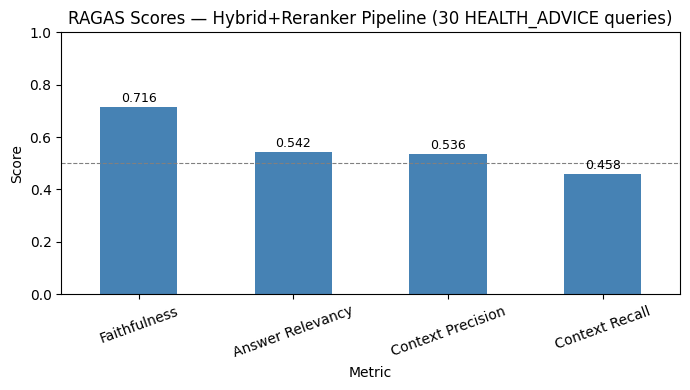

Saved: reports/en/ragas_scores.png


In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
df['Score'].plot(
    kind='bar', ax=ax,
    title='RAGAS Scores — Hybrid+Reranker Pipeline (30 HEALTH_ADVICE queries)',
    ylim=(0, 1), rot=20, color='steelblue'
)
ax.set_ylabel('Score')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

for i, v in enumerate(df['Score']):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('reports/en/ragas_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/en/ragas_scores.png')